# Separable template sky recovery

Model $T(\theta,f)=\sum_i \mathrm{flux}_i(\theta)\,\mathrm{shape}_i(f)$ (2 templates) fit to
**real ULSA** data with `lusee.fitting`: template maps are the *linear* block, spectral
shapes the *non-linear* block (the bilinear case).

We show the **gauge-invariant** total flux at low/mid/high frequency (recovered vs ULSA)
and the two recovered spectral shapes. Run `python notebooks/separable_fit_demo.py` first
to produce `separable_fit_result.npz`.

In [1]:
%matplotlib inline
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

d = np.load('separable_fit_result.npz')
freq = np.asarray(d['freq']); test_freq = np.asarray(d['test_freq'])
lmax = int(d['lmax']); Nside = int(d['Nside']); ref_freq = float(d['ref_freq'])
shapes_true = d['shapes_true']; shapes_hat = d['shapes_hat']; shape_init = d['shape_init']
ulsa_test = d['ulsa_test']; rec_test = d['rec_test']
print(f'lmax={lmax}  Nside={Nside}  ref_freq={ref_freq} MHz  '
      f'n_templates={shapes_true.shape[0]}  test_freq={test_freq.tolist()} MHz')

lmax=31  Nside=16  ref_freq=25.0 MHz  n_templates=3  test_freq=[15.0, 30.0, 45.0] MHz


## Total flux at low / mid / high frequency (gauge-invariant): ULSA vs recovered

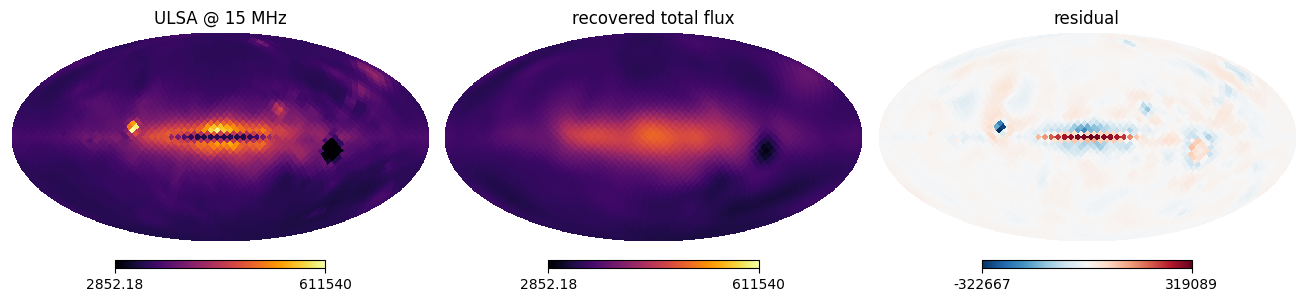

  f=15 MHz: residual RMS = 27557 K (38.9% of ULSA std)


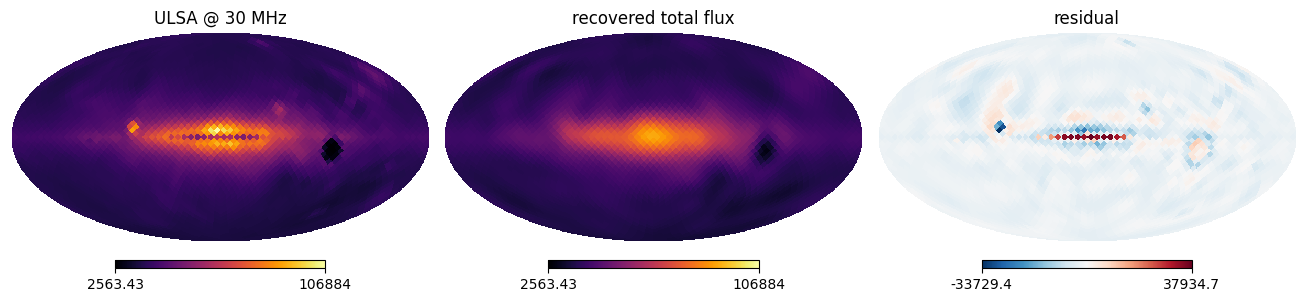

  f=30 MHz: residual RMS = 3114 K (23.5% of ULSA std)


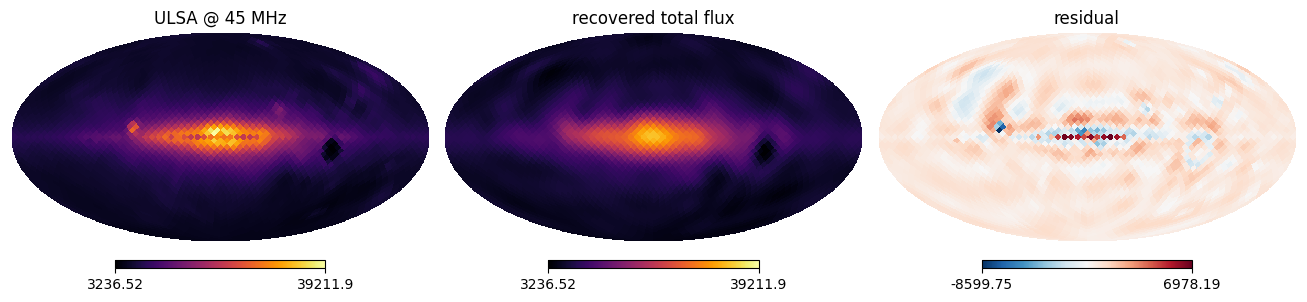

  f=45 MHz: residual RMS = 841 K (16.8% of ULSA std)


In [2]:
for k, f in enumerate(test_freq):
    tru = ulsa_test[k]; rec = rec_test[k]
    vmin, vmax = float(tru.min()), float(tru.max())
    plt.figure(figsize=(13, 3.4))
    hp.mollview(tru, sub=(1, 3, 1), title=f'ULSA @ {f:.0f} MHz', cmap='inferno', min=vmin, max=vmax)
    hp.mollview(rec, sub=(1, 3, 2), title='recovered total flux', cmap='inferno', min=vmin, max=vmax)
    hp.mollview(rec - tru, sub=(1, 3, 3), title='residual', cmap='RdBu_r')
    plt.show()
    print(f'  f={f:.0f} MHz: residual RMS = {np.sqrt(np.mean((rec-tru)**2)):.0f} K '
          f'({100*np.sqrt(np.mean((rec-tru)**2))/np.std(tru):.1f}% of ULSA std)')

## Spectral shapes: truth (rank-2 PCA) vs recovered

Both shapes are anchored to 1 at the reference frequency. The individual shapes are
defined only up to a mixing of the two templates (gauge freedom broken at the MAP by
the per-template $C_\ell$ priors); the total flux above is the unambiguous quantity.

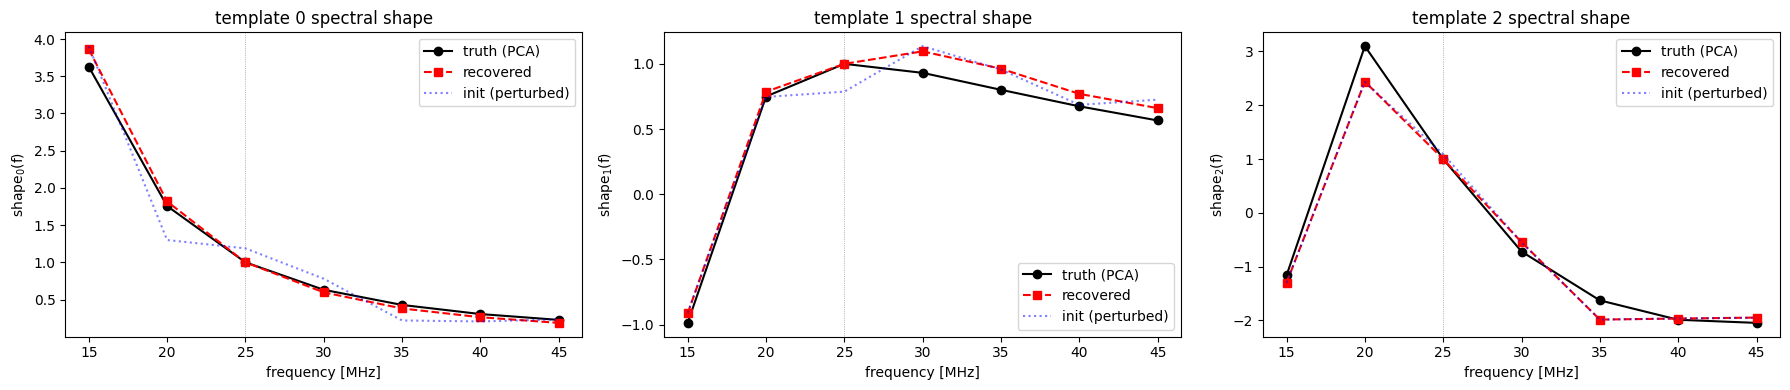

In [3]:
n_templ = shapes_true.shape[0]
fig, axs = plt.subplots(1, n_templ, figsize=(6 * n_templ, 4))
axs = np.atleast_1d(axs)
for i in range(n_templ):
    ax = axs[i]
    ax.plot(freq, shapes_true[i], 'k-o', label='truth (PCA)')
    ax.plot(freq, shapes_hat[i], 'r--s', label='recovered')
    ax.plot(freq, shape_init[i], 'b:', alpha=0.5, label='init (perturbed)')
    ax.axvline(ref_freq, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('frequency [MHz]'); ax.set_ylabel(f'shape$_{i}$(f)')
    ax.set_title(f'template {i} spectral shape'); ax.legend()
plt.tight_layout(); plt.show()

## Optimiser convergence ($\chi^2$ vs evaluation)

Per-evaluation $\chi^2$ (with line-search trials) and the running minimum. The
$\chi^2$ floor is the rank-$n$ model-mismatch level; `converged` reports whether
L-BFGS-B met its tolerance before `maxiter`.

In [ ]:
if 'chi2_history' not in d.files:
    print('No chi2_history in this npz -- re-run the fit (driver now saves it).')
else:
    hist = np.asarray(d['chi2_history'])
    ev = np.arange(1, len(hist) + 1)
    runmin = np.minimum.accumulate(hist)
    conv = bool(d['converged']) if 'converged' in d.files else None
    plt.figure(figsize=(7, 4))
    plt.semilogy(ev, hist, '.', ms=3, alpha=0.4, label='per evaluation')
    plt.semilogy(ev, runmin, '-', lw=2, label='running minimum')
    plt.xlabel('function evaluation'); plt.ylabel(r'$\chi^2$')
    plt.title(f'optimiser convergence (converged={conv})')
    plt.legend(); plt.tight_layout(); plt.show()
    print(f'final chi2 = {hist[-1]:.4e}  over {len(hist)} evals  (converged={conv})')

## HMC posterior: total flux (gauge-invariant) — mean & per-pixel SNR

The total flux at each frequency is a derived per-sample quantity, so the HMC
gives its posterior **mean** (a Bayesian-averaged estimate that de-overfits the
MAP) and per-pixel **std** (the SNR map) directly — unaffected by the
template-gauge freedom.

In [ ]:
if 'flux_post_mean_test' not in d.files:
    print('No HMC products -- run the demo with sample=True.')
else:
    pm = np.asarray(d['flux_post_mean_test']); ps = np.asarray(d['flux_post_std_test'])
    ut = np.asarray(d['ulsa_test'])
    for k, f in enumerate(test_freq):
        vmin, vmax = float(ut[k].min()), float(ut[k].max())
        plt.figure(figsize=(13, 3.4))
        hp.mollview(ut[k], sub=(1, 3, 1), title=f'ULSA @ {f:.0f} MHz', cmap='inferno', min=vmin, max=vmax)
        hp.mollview(pm[k], sub=(1, 3, 2), title='HMC posterior mean (total flux)', cmap='inferno', min=vmin, max=vmax)
        hp.mollview(ps[k], sub=(1, 3, 3), title=r'posterior $\sigma$ (per pixel)', cmap='viridis')
        plt.show()
        print(f'  f={f:.0f} MHz: post-mean resid {100*np.std(pm[k]-ut[k])/np.std(ut[k]):.0f}% of ULSA std; '
              f'median per-pixel SNR = {np.median(np.abs(pm[k])/np.maximum(ps[k],1e-9)):.0f}')

## Spectral shapes with HMC error bars

Posterior mean ± std for each template's spectral shape (anchored to 1 at the
reference frequency). The error bars are the direct per-frequency SNR; wide bars
flag the gauge/degenerate directions the data can't pin down.

In [ ]:
if 'shapes_post_mean' not in d.files:
    print('No HMC shape products -- run the demo with sample=True.')
else:
    sm = np.asarray(d['shapes_post_mean']); ss = np.asarray(d['shapes_post_std'])
    st = np.asarray(d['shapes_true']); nt = sm.shape[0]
    fig, axs = plt.subplots(1, nt, figsize=(6 * nt, 4)); axs = np.atleast_1d(axs)
    for i in range(nt):
        ax = axs[i]
        ax.plot(freq, st[i], 'k-o', label='truth (PCA)')
        ax.errorbar(freq, sm[i], yerr=ss[i], fmt='r--s', capsize=3,
                    label='HMC mean ± std')
        ax.axvline(ref_freq, color='gray', lw=0.5, ls=':')
        ax.set_xlabel('frequency [MHz]'); ax.set_ylabel(f'shape$_{i}$(f)')
        ax.set_title(f'template {i}'); ax.legend()
    plt.tight_layout(); plt.show()
    print('shape posterior median sigma per template:',
          np.round(np.median(ss, axis=1), 3).tolist())